$$
\providecommand{\bm}{\boldsymbol}
\providecommand{\R}{\mathbb{R}}
\providecommand{\xv}{\mathbf{x}}
\providecommand{\yv}{\mathbf{y}}
\providecommand{\thetav}{\bm{\theta}}
\providecommand{\thetab}{\bm{\theta}}
\providecommand{\Xmat}{\mathbf{X}}
\providecommand{\Remp}{\mathcal{R}_{\text{emp}}}
$$

INSERT_setup_intro

Warning message:
"package 'gridExtra' was built under R version 4.4.3"


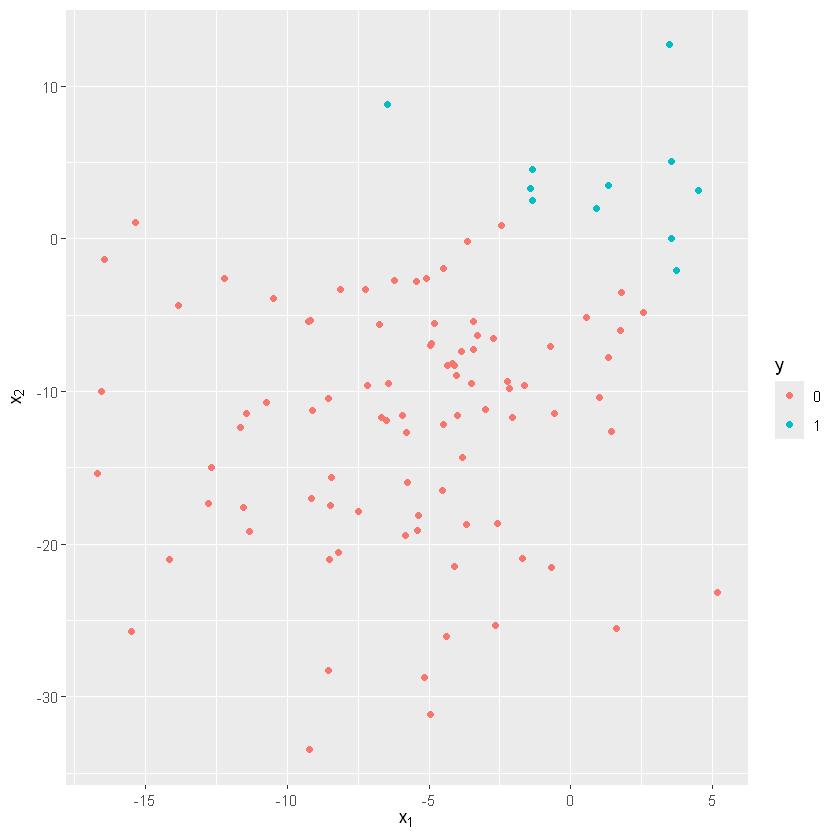

In [1]:
#| label: setup_data
library(ggplot2)
library(gridExtra)

set.seed(314)
n <- 100
X <- cbind(rnorm(n, -5, 5), rnorm(n, -10, 10))
z <- 2 * X[, 1] + 3 * X[, 2]
pr <- 1 / (1 + exp(-z))
y <- as.integer(pr > 0.5)
df <- data.frame(X = X, y = y)

ggplot(df) +
  geom_point(aes(x = X.1, y = X.2, color = as.factor(y))) +
  xlab(expression(x[1])) +
  ylab(expression(x[2])) +
  labs(colour = "y")

INSERT_seeds_note

INSERT_problem_intro

INSERT_problem_a

**Solution.**

INSERT_solution_a_text

INSERT_problem_b

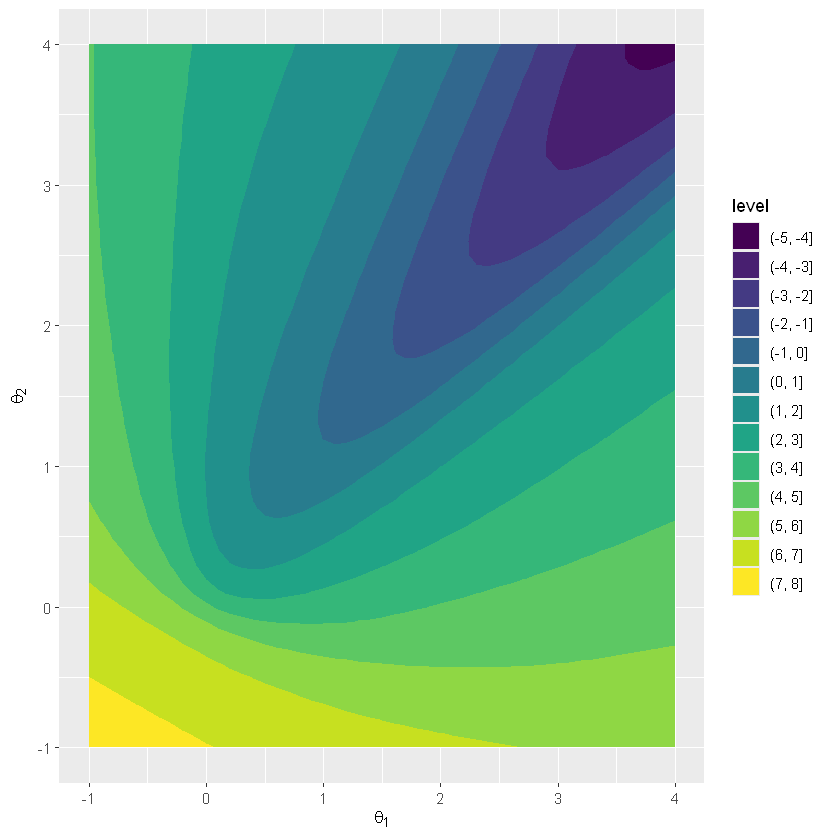

In [2]:
#| label: solution_b_code
# Empirical risk (lambda = 0 -> unregularized)
f <- function(theta, lambda) {
  z <- X %*% theta
  lambda * (theta %*% theta) + sum(-y * z + log(1 + exp(z)))
}

x <- seq(-1, 4, by = 0.1)
xx <- expand.grid(X1 = x, X2 = x)
# log-scale (as in (f)) to reveal the level-set shape across the wide range
fxx <- log(apply(xx, 1, function(t) f(t, 0)))
df_grid <- data.frame(xx, fxx = fxx)

ggplot(df_grid, aes(x = X1, y = X2, z = fxx)) +
  geom_contour_filled() +
  xlab(expression(theta[1])) +
  ylab(expression(theta[2]))

INSERT_solution_b_text

INSERT_problem_c

**Solution.**

INSERT_solution_c_text

INSERT_problem_d

vanilla a=0.01         final theta = ( 3.9867,  4.9332), ||theta|| =   6.343, R_emp = 0.015


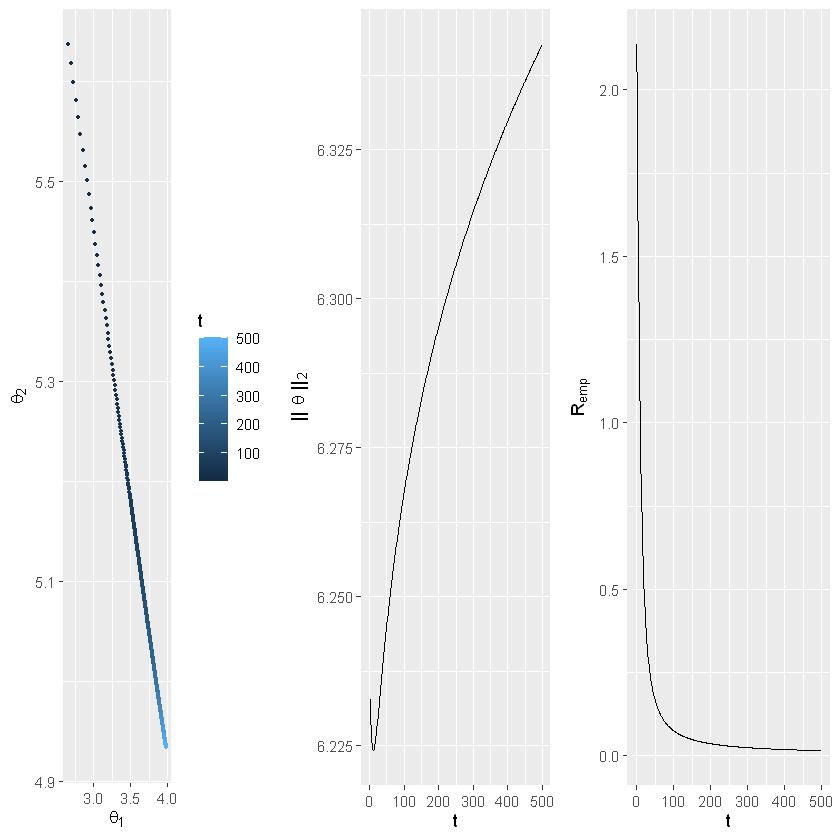

vanilla a=0.02         final theta = ( 7.1181, 10.2754), ||theta|| =  12.500, R_emp = 0.006


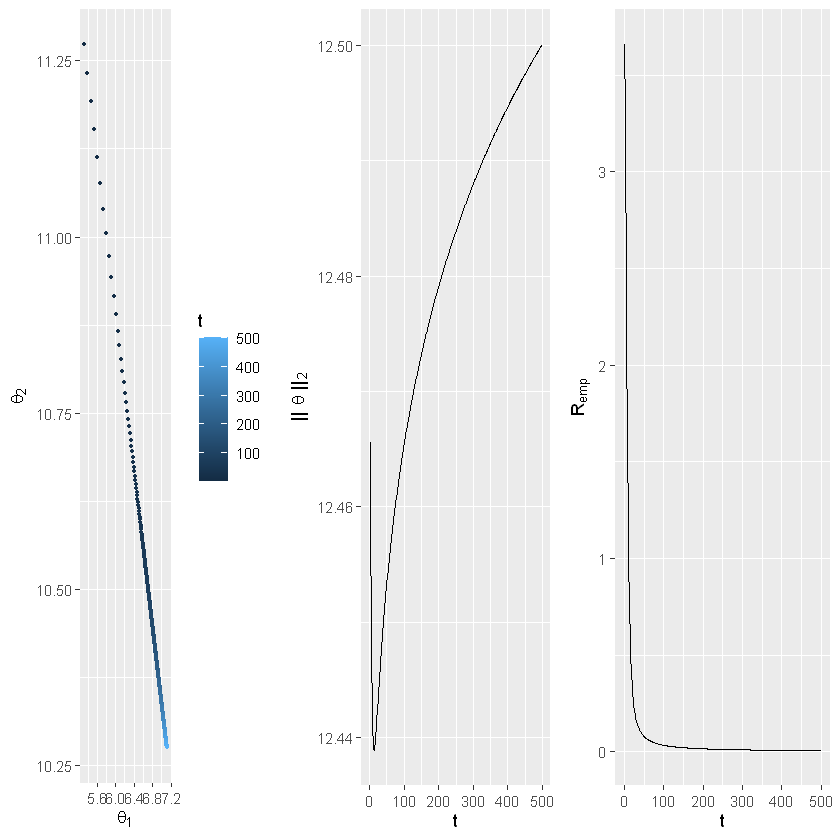

In [3]:
#| label: solution_d_code
# Gradient of the (regularized) logistic empirical risk.
# Returns a 1x2 row vector. NOTE: the regularizer contributes 2*lambda*theta.
df_t <- function(theta, lambda) {
  2 * lambda * t(theta) - (t(y) %*% X) +
    t(1 / (1 + exp(-X %*% theta))) %*% X
}

gd_step <- function(theta, alpha, lambda) {
  theta - alpha * df_t(theta, lambda)[1, ]
}

# Run GD for n_iters; show trace, ||theta||, R_emp; print + return final state.
plot_fun <- function(step_fn, lambda, n_iters = 500, label = "") {
  theta <- c(0, 0)
  thetas <- matrix(NA, n_iters, 2)
  norms <- numeric(n_iters)
  fs <- numeric(n_iters)
  for (i in 1:n_iters) {
    theta <- step_fn(theta)        # one GD-style update
    thetas[i, ] <- theta
    norms[i] <- sqrt(sum(theta^2))
    fs[i] <- f(theta, lambda)
  }
  df_trace <- data.frame(thetas, t = 1:n_iters)
  trace_plot <- ggplot(df_trace, aes(x = X1, y = X2, colour = t)) +
    geom_point(size = 0.7) +
    xlab(expression(theta[1])) + ylab(expression(theta[2]))
  norm_plot <- ggplot(data.frame(t = 1:n_iters, n = norms), aes(t, n)) +
    geom_line() + ylab(expression("||" ~ theta ~ "||"[2]))
  remp_plot <- ggplot(data.frame(t = 1:n_iters, fs = fs), aes(t, fs)) +
    geom_line() + ylab(expression(R[emp]))
  grid.arrange(trace_plot, norm_plot, remp_plot, ncol = 3)
  cat(sprintf(paste0(
    "%-22s final theta = (%7.4f, %7.4f), ",
    "||theta|| = %7.3f, R_emp = %.3f\n"),
              label, thetas[n_iters, 1], thetas[n_iters, 2],
              norms[n_iters], fs[n_iters]))
  invisible(list(thetas = thetas, norms = norms, fs = fs))
}

## alpha = 0.01, lambda = 0 (vanilla GD, unregularized)
plot_fun(function(theta) gd_step(theta, 0.01, 0), lambda = 0,
         label = "vanilla a=0.01")
## alpha = 0.02, lambda = 0
plot_fun(function(theta) gd_step(theta, 0.02, 0), lambda = 0,
         label = "vanilla a=0.02")

INSERT_solution_d_text

INSERT_problem_e

reg a=0.01             final theta = ( 0.6985,  0.8986), ||theta|| =   1.138, R_emp = 2.985


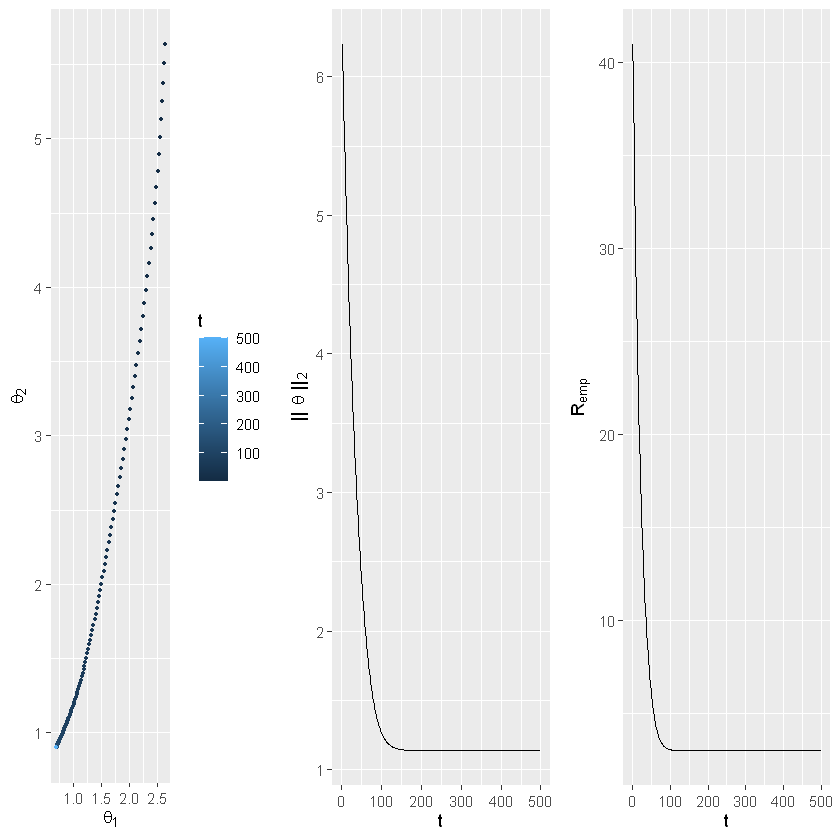

reg a=0.02             final theta = ( 0.6985,  0.8986), ||theta|| =   1.138, R_emp = 2.985


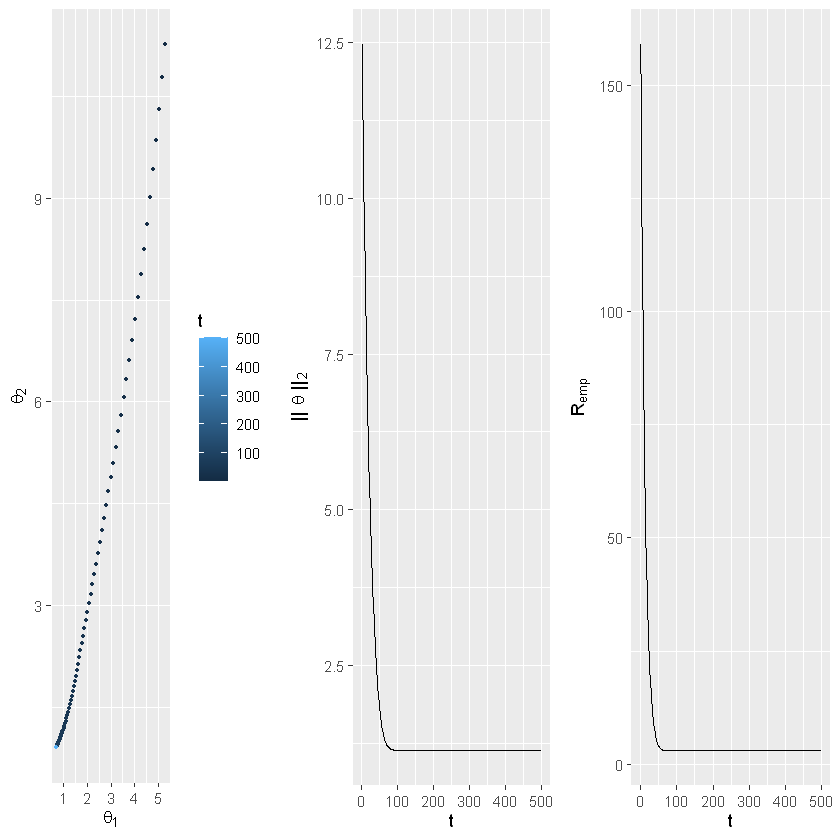

In [4]:
#| label: solution_e_code
## lambda = 1, alpha = 0.01
plot_fun(function(theta) gd_step(theta, 0.01, 1), lambda = 1,
         label = "reg a=0.01    ")
## lambda = 1, alpha = 0.02
plot_fun(function(theta) gd_step(theta, 0.02, 1), lambda = 1,
         label = "reg a=0.02    ")

INSERT_solution_e_text

INSERT_problem_f

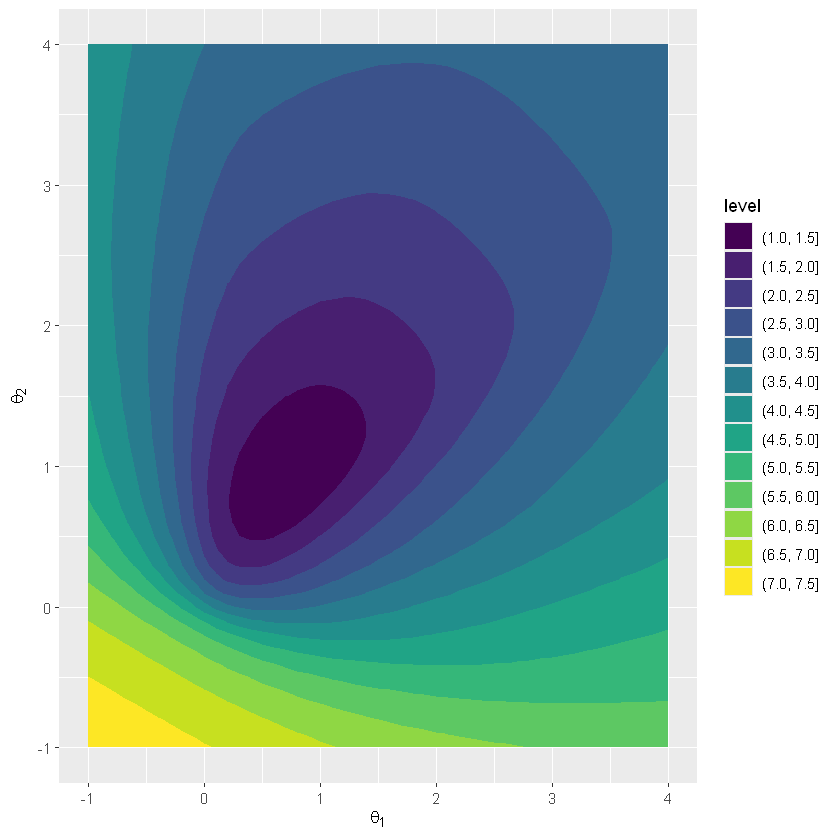

In [5]:
#| label: solution_f_code
fxx_reg <- log(apply(xx, 1, function(t) f(t, 1)))
df_grid_reg <- data.frame(xx, fxx = fxx_reg)

ggplot(df_grid_reg, aes(x = X1, y = X2, z = fxx)) +
  geom_contour_filled() +
  xlab(expression(theta[1])) +
  ylab(expression(theta[2]))

INSERT_solution_f_text

INSERT_problem_g

backtrack a=0.01       final theta = ( 0.6985,  0.8986), ||theta|| =   1.138, R_emp = 2.985


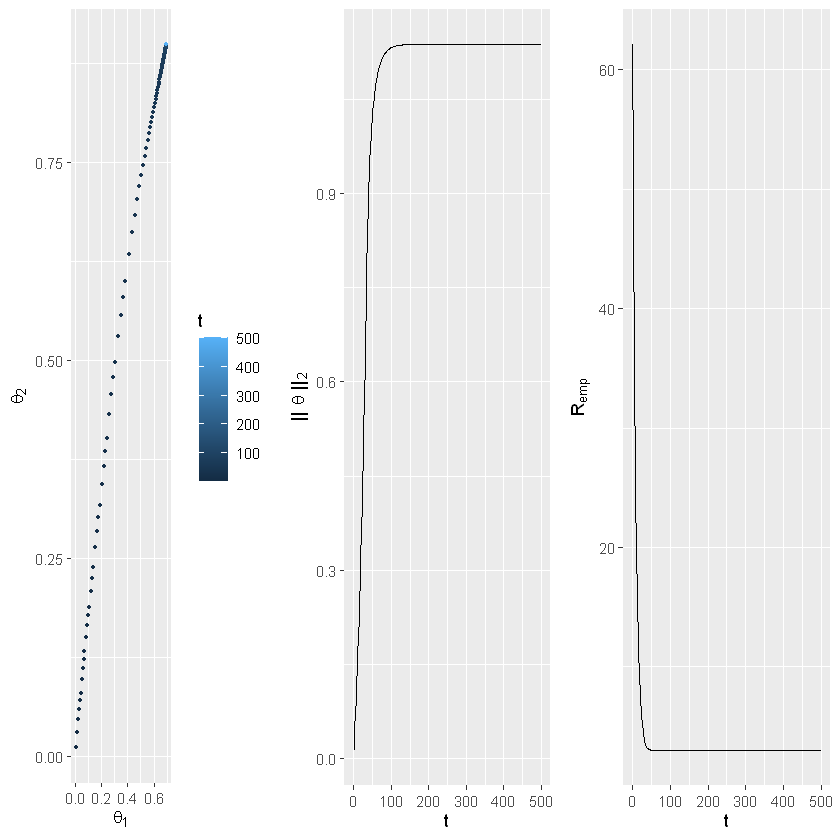

backtrack a=0.02       final theta = ( 0.6985,  0.8986), ||theta|| =   1.138, R_emp = 2.985


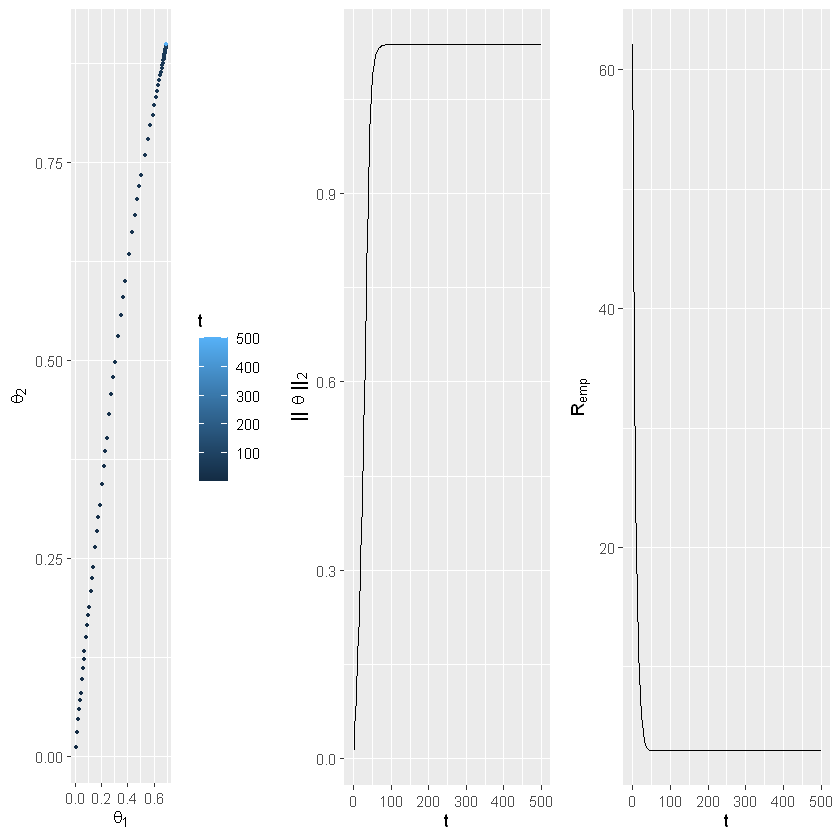

In [6]:
#| label: solution_g_code
gd_backtracking_step <- function(theta, alpha, gamma, tau, lambda) {
  f_theta <- f(theta, lambda)
  d_theta <- df_t(theta, lambda)[1, ]
  for (i in 1:1000) {
    theta_prop <- theta - alpha * d_theta
    if (f(theta_prop, lambda) <= f_theta - gamma * alpha * sum(d_theta^2)) {
      return(theta_prop)
    }
    alpha <- tau * alpha
  }
  stop("backtracking failed to find a descent step after 1000 shrinks; ",
       "check curvature / starting point / gamma=", gamma)
}

## lambda = 1, alpha_init = 0.01
result_bt <- plot_fun(
  function(theta) gd_backtracking_step(theta, 0.01, 0.9, 0.5, 1),
  lambda = 1, label = "backtrack a=0.01")
## lambda = 1, alpha_init = 0.02
plot_fun(
  function(theta) gd_backtracking_step(theta, 0.02, 0.9, 0.5, 1),
  lambda = 1, label = "backtrack a=0.02")

INSERT_solution_g_text